In [106]:
import pandas as pd
import seaborn as sns
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [107]:
# Load dataset

df= sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [108]:
df.shape

(891, 15)

There is 891 rows and 15 columns.

# Column's description
survived: survival (0 = No, 1 = Yes)
pclass:  Ticket class (1st, 2nd, 3rd)
age: Age in years
sibsp: Number of siblings/spouses
parch: :No. of parents / children aboard the Titanic
fare: Ticket price.
embarked: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
clas: Same as pclass (First, Second, Third)
who: Categorization of passengers as man, woman, or child
adult_male: Boolean indicating if the passenger is an adult male
deck: The deck level where the passenger cabin was located
embark_town: The full name of the town of embarkation.
alive: Descriptive version of survived (yes/no)
alone: Boolean indicating if the passenger was traveling without family.



The target column of this dataset is survived and others are independent feature

Data Analysis

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [110]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

We found 177 NaN value for age column,
embark_town and embark have 2 Nan,
deck have 688 Nan which is the highest

In [111]:
df1 = df.copy()
df2 = df.copy()
df1.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [112]:
df1.columns
df1 = df1.drop('class', axis= 1)
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,NaN,Southampton,no,True


In [113]:
df1.columns
df1 = df1.drop('embarked', axis= 1)
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,no,True


In [114]:
df1 = df1.drop('alive', axis= 1)
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,True


In [115]:
df1.duplicated().sum()

np.int64(107)

We will remove the duplicates

In [116]:
df1 = df1.drop_duplicates()
df1.duplicated().sum()

np.int64(0)

In [117]:
df1['survived'].value_counts()

survived
0    461
1    323
Name: count, dtype: int64

461 people died, 
323 people survived

In [118]:
df1['embark_town'].value_counts()

embark_town
Southampton    568
Cherbourg      155
Queenstown      59
Name: count, dtype: int64

Most people get in the ship from southampton it is 568, 
Least people was from Queenstown and from cherbourg 155 people get in the ship.

In [119]:
df1.columns
df1['sex'].value_counts()

sex
male      491
female    293
Name: count, dtype: int64

Males passegers were more than the female passengers

In [120]:
df1.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'deck', 'embark_town', 'alone'],
      dtype='object')

In [121]:
df1['pclass'].value_counts()

pclass
3    405
1    214
2    165
Name: count, dtype: int64

Most of the passenger took third class ticket. 
214 people took first class and 165 people took second class ticket

In [122]:
df1['sibsp'].value_counts()

sibsp
0    517
1    201
2     27
4     18
3     14
5      5
8      2
Name: count, dtype: int64

Most of the people were alone. A remarked amount of people was travelling dual.

In [123]:
df1['adult_male'].value_counts()

adult_male
True     451
False    333
Name: count, dtype: int64

451 male was adult that means young. 
333 male was not adult. Here women also count as false. So womens are also count as not adult men.

In [124]:
df1['alone'].value_counts()

alone
True     446
False    338
Name: count, dtype: int64

446 people were travelling alone.

In [125]:
df1.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'deck', 'embark_town', 'alone'],
      dtype='object')

In [126]:
df1.groupby('pclass')['survived'].sum()

pclass
1    135
2     84
3    104
Name: survived, dtype: int64

Total 323 people survived means (survived = 1). Here 135 people from first class. 84 people from second class and 104 people from the third class.

In [127]:
df1['survived'].value_counts()

survived
0    461
1    323
Name: count, dtype: int64

In [128]:
df1.groupby('sex')['survived'].sum()

sex
female    217
male      106
Name: survived, dtype: int64

217 Female survived the accident. On the other hand, 106 Male survived the accident

In [129]:
df1.groupby('embark_town')['survived'].sum()

embark_town
Cherbourg       90
Queenstown      20
Southampton    211
Name: survived, dtype: int64

In [130]:
df1.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'deck', 'embark_town', 'alone'],
      dtype='object')

In [131]:
df1.groupby('pclass')['survived'].value_counts()

pclass  survived
1       1           135
        0            79
2       1            84
        0            81
3       0           301
        1           104
Name: count, dtype: int64

In [132]:
df1.groupby('sex')['survived'].value_counts()

sex     survived
female  1           217
        0            76
male    0           385
        1           106
Name: count, dtype: int64

In [133]:
df1.groupby('embark_town')['survived'].value_counts()

embark_town  survived
Cherbourg    1            90
             0            65
Queenstown   0            39
             1            20
Southampton  0           357
             1           211
Name: count, dtype: int64

In [134]:
df1['died'] = 1 - df1['survived'] #create a new column named died
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,True,1


Data Cleaning.

We will clean Nan value. Duplicates

In [135]:
df3 = df1.copy()
df4 = df1.copy()
df3

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,woman,False,NaN,Queenstown,False,1
887,1,1,female,19.0,0,0,30.0000,woman,False,B,Southampton,True,0
888,0,3,female,NaN,1,2,23.4500,woman,False,NaN,Southampton,False,1
889,1,1,male,26.0,0,0,30.0000,man,True,C,Cherbourg,True,0


In [136]:
df[df['who']=='child']

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
7,0,3,male,2.00,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
9,1,2,female,14.00,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
10,1,3,female,4.00,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
14,0,3,female,14.00,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True
16,0,3,male,2.00,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,NaN,Southampton,yes,False
850,0,3,male,4.00,4,2,31.2750,S,Third,child,False,NaN,Southampton,no,False
852,0,3,female,9.00,1,1,15.2458,C,Third,child,False,NaN,Cherbourg,no,False
869,1,3,male,4.00,1,1,11.1333,S,Third,child,False,NaN,Southampton,yes,False


In [137]:
# Nan value remove

df1.isna().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
who              0
adult_male       0
deck           582
embark_town      2
alone            0
died             0
dtype: int64

In [138]:
df1.shape

(784, 13)

In [139]:
df3.dropna(inplace= True)
df3.shape

(181, 13)

Because df3 is a copy of df1 before I dropped the 'deck' column, the 'deck' column is still present in df3.

The 'deck' column is roughly 77% missing values (688 NaNs).

In [140]:
df3.duplicated().sum()

np.int64(0)

In [141]:
age_mean = df1['age'].mean()
age_mean

df1['age'] = df1['age'].fillna(age_mean)
df1['age'].isna().sum()
df1.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
who              0
adult_male       0
deck           582
embark_town      2
alone            0
died             0
dtype: int64

The Nan in age was removed by the comlun's mean.

In [142]:
# embark_town nan removal 

emb_town_mode = df1['embark_town'].mode()[0]

In [143]:
df1.shape

(784, 13)

In [144]:
df1['embark_town'] = df1['embark_town'].fillna(emb_town_mode)
df1.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
who              0
adult_male       0
deck           582
embark_town      0
alone            0
died             0
dtype: int64

Deck has a lot of Nan value.
So we will remove the column.

In [145]:
df1.columns
df1 = df1.drop('deck', axis= 1)
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [146]:
# Handle the Outliers in age column

def outliers(col, df):
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)

    iqr = q3 - q1

    upper_whisker = q3 + 1.5 * iqr
    lower_whisker = q1 - 1.5 * iqr

    return df[(df[col] <= upper_whisker) & (df[col] >= lower_whisker)]

<Axes: ylabel='age'>

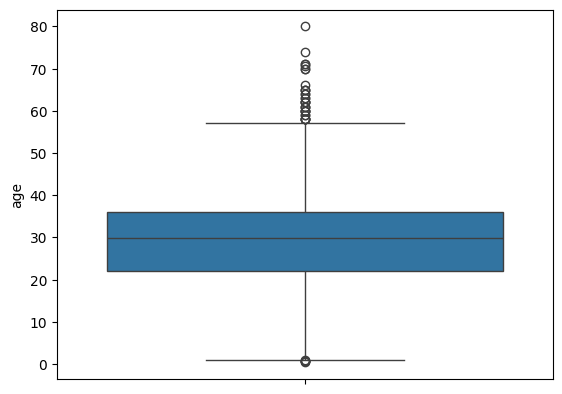

In [147]:
sns.boxplot(df1['age'])

In [148]:
new_df = outliers('age', df1)
new_df.shape

(745, 12)

<Axes: ylabel='age'>

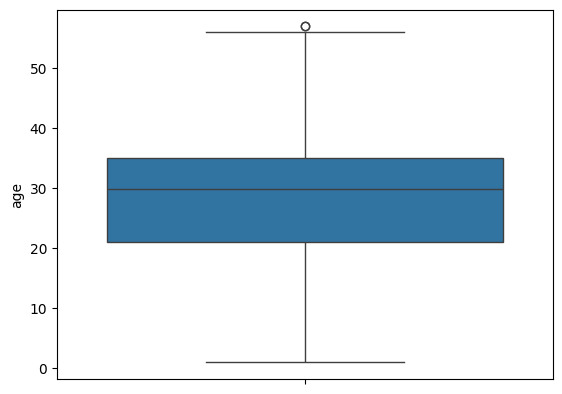

In [149]:
sns.boxplot(new_df['age'])

Data Preprocessing 


In [150]:
new_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [151]:
new_df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
who            0
adult_male     0
embark_town    0
alone          0
died           0
dtype: int64

In [152]:
new_df.dropna(inplace= True)
new_df.shape

C:\Users\bikra\AppData\Local\Temp\ipykernel_4968\2995483227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.dropna(inplace= True)


(745, 12)

In [153]:
df5 = new_df.copy()
df6 = new_df.copy()
df7 = new_df.copy()
df8 = new_df.copy()

In [154]:
df5['adult_male'] = df5['adult_male'].astype('int64')
df5.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,1,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,0,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,0,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,0,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,1,Southampton,True,1


In [155]:
df5['alone'].value_counts()

alone
True     422
False    323
Name: count, dtype: int64

In [156]:
df5['alone'] = df5['alone'].astype('int64')
df5.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,1,Southampton,0,1
1,1,1,female,38.0,1,0,71.2833,woman,0,Cherbourg,0,0
2,1,3,female,26.0,0,0,7.9250,woman,0,Southampton,1,0
3,1,1,female,35.0,1,0,53.1000,woman,0,Southampton,0,0
4,0,3,male,35.0,0,0,8.0500,man,1,Southampton,1,1


Encoding Using Replace

In [157]:
df5['who'].value_counts()

who
man      425
woman    244
child     76
Name: count, dtype: int64

In [158]:
df5['who'] = df5['who'].replace(['man', 'woman', 'child'],[1, 2, 0])

C:\Users\bikra\AppData\Local\Temp\ipykernel_4968\2450840783.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df5['who'] = df5['who'].replace(['man', 'woman', 'child'],[1, 2, 0])


In [159]:
df5['who'].value_counts()

who
1    425
2    244
0     76
Name: count, dtype: int64

In [160]:
df6.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [161]:
df6.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'embark_town', 'alone', 'died'],
      dtype='object')

In [162]:
from numpy._core.defchararray import count
from pandas.api.types import is_numeric_dtype


for col in df6.columns:
    if not is_numeric_dtype(df6[col]):
        uniq = df6[col].unique().tolist() #['male', 'female']
        coun = df6[col].nunique() # 2

        if coun == 2:
            df6[col] = df6[col].replace(uniq, [0, 1])
        
        if coun == 3:
            df6[col] = df6[col].replace(uniq, [0, 1, 2])
        
        if coun == 4:
            df6[col] = df6[col].replace(uniq, [0, 1, 2, 3])

C:\Users\bikra\AppData\Local\Temp\ipykernel_4968\1259177931.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df6[col] = df6[col].replace(uniq, [0, 1])
C:\Users\bikra\AppData\Local\Temp\ipykernel_4968\1259177931.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df6[col] = df6[col].replace(uniq, [0, 1, 2])


In [163]:
df6.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,0,22.0,1,0,7.2500,0,True,0,False,1
1,1,1,1,38.0,1,0,71.2833,1,False,1,False,0
2,1,3,1,26.0,0,0,7.9250,1,False,0,True,0
3,1,1,1,35.0,1,0,53.1000,1,False,0,False,0
4,0,3,0,35.0,0,0,8.0500,0,True,0,True,1


In [164]:
df2['sex'].nunique()

2

In [165]:
#df2['sex'].unique() this gives array. We convert it into list.
# As in replace we give a list 
df2['sex'].unique().tolist()


['male', 'female']

In [166]:
df3.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
who            0
adult_male     0
deck           0
embark_town    0
alone          0
died           0
dtype: int64

Encoding Tecqniues

In [167]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [168]:
le = LabelEncoder()

In [169]:
df7.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [170]:
df7['sex'] = le.fit_transform(df7['sex'])

In [171]:
df7['sex'].value_counts()

sex
1    460
0    285
Name: count, dtype: int64

In [172]:
df9 = new_df.copy()
df10 = new_df.copy()
df11 = new_df.copy()
df12 = new_df.copy()

In [173]:
df7.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,1,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,0,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,0,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,0,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,1,35.0,0,0,8.0500,man,True,Southampton,True,1


In [174]:
df7['embark_town'].value_counts()

embark_town
Southampton    543
Cherbourg      145
Queenstown      57
Name: count, dtype: int64

Ordinal Encoding

In [175]:
# Ordinal Encoding

ord = OrdinalEncoder()

In [176]:
df7['embark_town'].value_counts()

embark_town
Southampton    543
Cherbourg      145
Queenstown      57
Name: count, dtype: int64

In [177]:
df7['embark_town']  = ord.fit_transform(df7[['embark_town']])

In [178]:
df7['embark_town'].value_counts()

embark_town
2.0    543
0.0    145
1.0     57
Name: count, dtype: int64

In [179]:
# fit then transform. separetely

df7['who'].value_counts()

who
man      425
woman    244
child     76
Name: count, dtype: int64

In [180]:
encode = le.fit(df7['who'])
df7.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,1,22.0,1,0,7.2500,man,True,2.0,False,1
1,1,1,0,38.0,1,0,71.2833,woman,False,0.0,False,0
2,1,3,0,26.0,0,0,7.9250,woman,False,2.0,True,0
3,1,1,0,35.0,1,0,53.1000,woman,False,2.0,False,0
4,0,3,1,35.0,0,0,8.0500,man,True,2.0,True,1


In [181]:
encode

LabelEncoder()

In [182]:
df7['who'] = encode.transform(df7['who'])
df7.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,1,22.0,1,0,7.2500,1,True,2.0,False,1
1,1,1,0,38.0,1,0,71.2833,2,False,0.0,False,0
2,1,3,0,26.0,0,0,7.9250,2,False,2.0,True,0
3,1,1,0,35.0,1,0,53.1000,2,False,2.0,False,0
4,0,3,1,35.0,0,0,8.0500,1,True,2.0,True,1


In [183]:
encode = ord.fit(df8[['embark_town']])

In [184]:
df8['embark_town'] = encode.transform(df8[['embark_town']])


In [185]:
df8.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,2.0,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,0.0,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,2.0,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,2.0,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,2.0,True,1


We use loop for every categorical data

In [186]:
# Using loop 

for col in df9.columns:
    if not is_numeric_dtype(df9[col]):
        df9[col] = ord.fit_transform(df9[[col]])

df9.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,1.0,22.0,1,0,7.2500,1.0,True,2.0,False,1
1,1,1,0.0,38.0,1,0,71.2833,2.0,False,0.0,False,0
2,1,3,0.0,26.0,0,0,7.9250,2.0,False,2.0,True,0
3,1,1,0.0,35.0,1,0,53.1000,2.0,False,2.0,False,0
4,0,3,1.0,35.0,0,0,8.0500,1.0,True,2.0,True,1


One-hot encoding.

Works with Binary.

In [187]:
# One-hot encoding
# Using dummy variable
                       
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output= False)

In [188]:
df10.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [189]:
dummy = pd.get_dummies(df10['who'], drop_first= True, prefix= 'who').astype('int64')
dummy

,who_man,who_woman
0,1,0
1,0,1
2,0,1
3,0,1
4,1,0
...,...,...
885,0,1
887,0,1
888,0,1
889,1,0


In [190]:
dummy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 745 entries, 0 to 890
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   who_man    745 non-null    int64
 1   who_woman  745 non-null    int64
dtypes: int64(2)
memory usage: 17.5 KB


In [191]:
df10 = df10.drop(['who'], axis= 1)

In [192]:
df10.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'adult_male', 'embark_town', 'alone', 'died'],
      dtype='object')

In [193]:
df10 = pd.concat([df10,dummy], axis= 1)
df10.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,embark_town,alone,died,who_man,who_woman
0,0,3,male,22.0,1,0,7.2500,True,Southampton,False,1,1,0
1,1,1,female,38.0,1,0,71.2833,False,Cherbourg,False,0,0,1
2,1,3,female,26.0,0,0,7.9250,False,Southampton,True,0,0,1
3,1,1,female,35.0,1,0,53.1000,False,Southampton,False,0,0,1
4,0,3,male,35.0,0,0,8.0500,True,Southampton,True,1,1,0


In [194]:
# try using loop by creating dummy method

#df11.head()

for col in df11.columns:
    if not is_numeric_dtype(df11[col]):
        dummy = pd.get_dummies(df11[col], drop_first= True, prefix= col).astype('int64')
        df11 = df11.drop([col], axis= 1)
        df11 = pd.concat([df11,dummy], axis= 1)


df11.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,died,sex_male,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,True,False,1,1,1,0,0,1
1,1,1,38.0,1,0,71.2833,False,False,0,0,0,1,0,0
2,1,3,26.0,0,0,7.9250,False,True,0,0,0,1,0,1
3,1,1,35.0,1,0,53.1000,False,False,0,0,0,1,0,1
4,0,3,35.0,0,0,8.0500,True,True,1,1,1,0,0,1


In [195]:
# one hot encoding using the algorithm.
# we need to do fit then transform otherwise one category will be eareased if fit_tranform applied.



In [196]:
df10['embark_town'].value_counts()

embark_town
Southampton    543
Cherbourg      145
Queenstown      57
Name: count, dtype: int64

In [197]:
encode = ohe.fit(df10[['embark_town']])

In [198]:
encode

OneHotEncoder(sparse_output=False)

In [199]:
encode_data = encode.transform(df10[['embark_town']]) 

In [200]:
encode_data

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]], shape=(745, 3))

In [201]:
data = pd.DataFrame(encode_data, columns= ohe.get_feature_names_out(['embark_town']))

In [202]:
data

,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
740,0.0,1.0,0.0
741,0.0,0.0,1.0
742,0.0,0.0,1.0
743,1.0,0.0,0.0


In [203]:
df10 = df10.drop(['embark_town'], axis= 1)

In [204]:
df10.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,died,who_man,who_woman
0,0,3,male,22.0,1,0,7.25,True,False,1,1,0


In [205]:
new_df10 = pd.concat([df10, data], axis= 1)

In [206]:
new_df10.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,died,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0.0,3.0,male,22.0,1.0,0.0,7.2500,True,False,1.0,1.0,0.0,0.0,0.0,1.0
1,1.0,1.0,female,38.0,1.0,0.0,71.2833,False,False,0.0,0.0,1.0,1.0,0.0,0.0
2,1.0,3.0,female,26.0,0.0,0.0,7.9250,False,True,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,1.0,female,35.0,1.0,0.0,53.1000,False,False,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,3.0,male,35.0,0.0,0.0,8.0500,True,True,1.0,1.0,0.0,0.0,0.0,1.0


In [207]:
df10['sex'].value_counts()

sex
male      460
female    285
Name: count, dtype: int64

In [208]:
encode = ohe.fit(df10[['sex']])

In [209]:
df10['sex'] = encode.transform(df10[['sex']])


In [210]:
df10.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,died,who_man,who_woman
0,0,3,0.0,22.0,1,0,7.2500,True,False,1,1,0
1,1,1,1.0,38.0,1,0,71.2833,False,False,0,0,1
2,1,3,1.0,26.0,0,0,7.9250,False,True,0,0,1
3,1,1,1.0,35.0,1,0,53.1000,False,False,0,0,1
4,0,3,0.0,35.0,0,0,8.0500,True,True,1,1,0


In [214]:
df12.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [215]:
df13 = df12.copy()
df14 = df12.copy()

The below process for one hot encoding is work for two variables.

But in three variables we should use the above one-hot encoding tenchnique algorithm.

In [217]:
df12.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,died
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,1
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,0
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,0
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,0
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,1


In [218]:
encode = ohe.fit(df12[['embark_town']])

In [219]:
encode

OneHotEncoder(sparse_output=False)

In [220]:
df12['embark_town'] = encode.transform(df12[['embark_town']])

In [223]:
df12['embark_town'].value_counts()

embark_town
0.0    600
1.0    145
Name: count, dtype: int64